In [1]:
import pandas as pd

esp_results = pd.read_csv("results_esp_proteins.csv")
esp_results["model"] = "ESP (state of the art)"

np_esm2_results = pd.read_csv("results_np_classifier_proteins.csv")
np_esm2_results["model"] = "Neural Network-NPClassifier-ESM2"
np_esm2_results = np_esm2_results.rename(columns={"f1_macro": "f1_score"})

prosmith = pd.read_csv("prosmith_results_proteins.csv")
prosmith["model"] = "ProSmith (state of the art)"

xgb_results = pd.read_csv("results_xgb_np_esm2_proteins.csv")
xgb_results["model"] = "XGBoost-NPClassifierFP-ESM2"

xgb_results_prot_bert = pd.read_csv("results_xgb_np_prot_bert_proteins.csv")
xgb_results_prot_bert["model"] = "XGBoost-NPClassifierFP-ProtBERT"

xgb_results_esm1b = pd.read_csv("results_xgb_np_esm1b_proteins.csv")
xgb_results_esm1b["model"] = "XGBoost-NPClassifierFP-ESM1b"

In [2]:
results = pd.concat(
    [
        esp_results,
        np_esm2_results,
        prosmith,
        xgb_results,
        xgb_results_prot_bert,
        xgb_results_esm1b
    ]
)
results


,accuracy,f1_score,recall,precision,roc_auc,mcc,seed,fold,identity,model
0,0.664923,0.654137,0.870799,0.523810,0.856279,0.411327,0,0.0,80,ESP (state of the art)
1,0.658876,0.646682,0.857916,0.518916,0.851913,0.395977,1,0.0,80,ESP (state of the art)
2,0.674706,0.660714,0.870426,0.532435,0.862259,0.424525,2,0.0,80,ESP (state of the art)
3,0.673415,0.657108,0.859970,0.531686,0.856703,0.417149,3,0.0,80,ESP (state of the art)
4,0.659692,0.646082,0.853622,0.519723,0.851061,0.394785,4,0.0,80,ESP (state of the art)
...,...,...,...,...,...,...,...,...,...,...
10,0.820148,0.777537,0.781998,0.773127,0.904699,0.626633,0,NaN,40,XGBoost-NPClassifierFP-ESM1b
11,0.824521,0.785457,0.799209,0.772171,0.909932,0.637352,1,NaN,40,XGBoost-NPClassifierFP-ESM1b
12,0.813310,0.770837,0.781207,0.760740,0.901611,0.613539,2,NaN,40,XGBoost-NPClassifierFP-ESM1b
13,0.824362,0.778901,0.769733,0.788290,0.904672,0.633375,3,NaN,40,XGBoost-NPClassifierFP-ESM1b


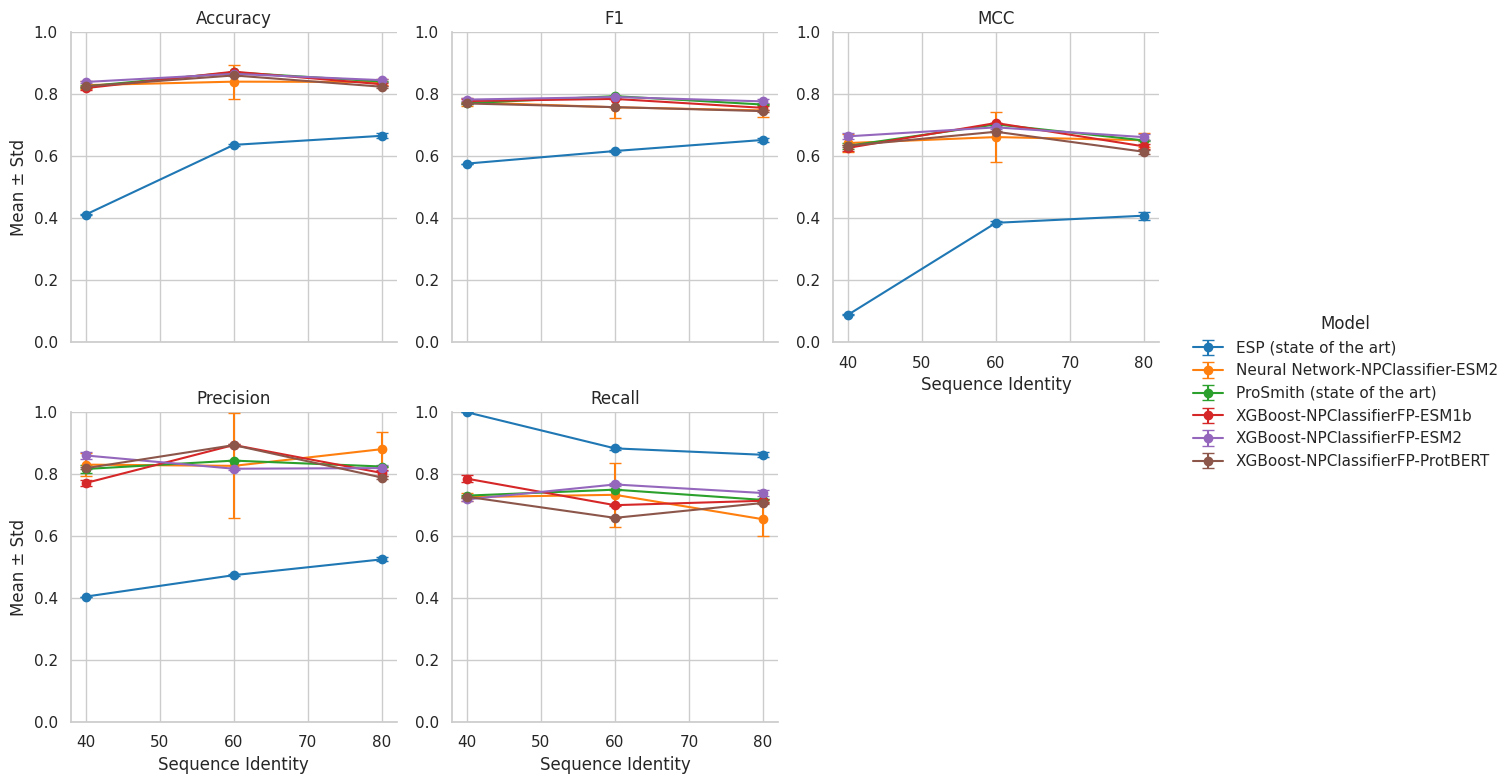

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Create a dictionary for column name mapping
column_mapping = {
    'f1_score': 'F1',
    'recall': 'Recall',
    'mcc': 'MCC',
    'precision': "Precision",
    'accuracy':"Accuracy"
}

# Rename columns in results dataframe
results = results.rename(columns=column_mapping)

# Melt for easier grouping
df_melted = results.melt(id_vars=['model', 'identity'],
                    value_vars=['Accuracy', 'F1', 'Recall', 'Precision', 'MCC'],
                    var_name='metric', value_name='value')

# Compute mean and std
summary_df = df_melted.groupby(['model', 'identity', 'metric']).agg(
    mean=('value', 'mean'),
    std=('value', 'std')
).reset_index()

# Set plot style
sns.set(style="whitegrid")
palette = sns.color_palette("tab10")

# Create FacetGrid
g = sns.FacetGrid(summary_df, col='metric', col_wrap=3, height=4, sharey=False, hue='model', palette=palette)

# Plot: lines + points + error bars
def plot_lines(data, color, **kwargs):
    # Sort by identity to ensure line plotting is correct
    data = data.sort_values('identity')
    plt.errorbar(data['identity'], data['mean'], yerr=data['std'], fmt='o-', 
                 capsize=4, color=color, label=data['model'].iloc[0])

g.map_dataframe(plot_lines)

# Titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("Sequence Identity", "Mean ± Std")
g.add_legend(title="Model")
g.set(ylim=(0, 1))  # Set y-axis limits to [0, 1] for better visibility
g.tight_layout()
plt.savefig("results_proteins.png", dpi=300, transparent=True)
plt.show()

In [4]:
import pandas as pd

np_esm2_results = pd.read_csv("results_np_classifier_compounds.csv")
np_esm2_results["model"] = "Neural Network-NPClassifier-ESM2"
np_esm2_results = np_esm2_results.rename(columns={"f1_macro": "f1_score"})

esp_results = pd.read_csv("results_esp_compounds.csv")
esp_results["model"] = "ESP (state of the art)"

prosmith = pd.read_csv("prosmith_results_compounds.csv")
prosmith["model"] = "ProSmith (state of the art)"

xgb_results = pd.read_csv("results_xgb_np_esm2_compounds.csv")
xgb_results["model"] = "XGBoost-NPClassifierFP-ESM2"


xgb_results_prot_bert = pd.read_csv("results_xgb_np_prot_bert_compounds.csv")
xgb_results_prot_bert["model"] = "XGBoost NPClassifierFP-ProtBERT"

xgb_results_esm1b = pd.read_csv("results_xgb_np_esm1b_compounds.csv")
xgb_results_esm1b["model"] = "XGBoost-NPClassifierFP-ESM1b"

results = pd.concat(
    [
        esp_results,
        np_esm2_results,
        prosmith,
        xgb_results,
        xgb_results_prot_bert,
        xgb_results_esm1b
    ]
)
results


,accuracy,f1_score,recall,precision,roc_auc,mcc,seed,fold,similarity,model
0,0.354455,0.358747,0.966561,0.220247,0.802876,0.182958,0,0.0,20,ESP (state of the art)
1,0.359661,0.360612,0.966561,0.221654,0.804926,0.187368,1,0.0,20,ESP (state of the art)
2,0.361148,0.360578,0.964172,0.221754,0.815399,0.186438,2,0.0,20,ESP (state of the art)
3,0.364421,0.361572,0.963376,0.222549,0.812632,0.188478,3,0.0,20,ESP (state of the art)
4,0.351926,0.358037,0.967357,0.219671,0.802797,0.181546,4,0.0,20,ESP (state of the art)
...,...,...,...,...,...,...,...,...,...,...
20,0.799792,0.612773,0.847930,0.479730,0.913495,0.527656,0,NaN,20,XGBoost-NPClassifierFP-ESM1b
21,0.809758,0.627222,0.856688,0.494713,0.919062,0.546274,1,NaN,20,XGBoost-NPClassifierFP-ESM1b
22,0.717388,0.532020,0.859873,0.385164,0.890117,0.430439,2,NaN,20,XGBoost-NPClassifierFP-ESM1b
23,0.738361,0.548163,0.849522,0.404626,0.889258,0.448919,3,NaN,20,XGBoost-NPClassifierFP-ESM1b


In [5]:
# Create a dictionary for column name mapping
column_mapping = {
    'f1_score': 'F1',
    'recall': 'Recall',
    'mcc': 'MCC',
    'precision': "Precision",
    'accuracy':"Accuracy"
}

# Rename columns in results dataframe
results = results.rename(columns=column_mapping)

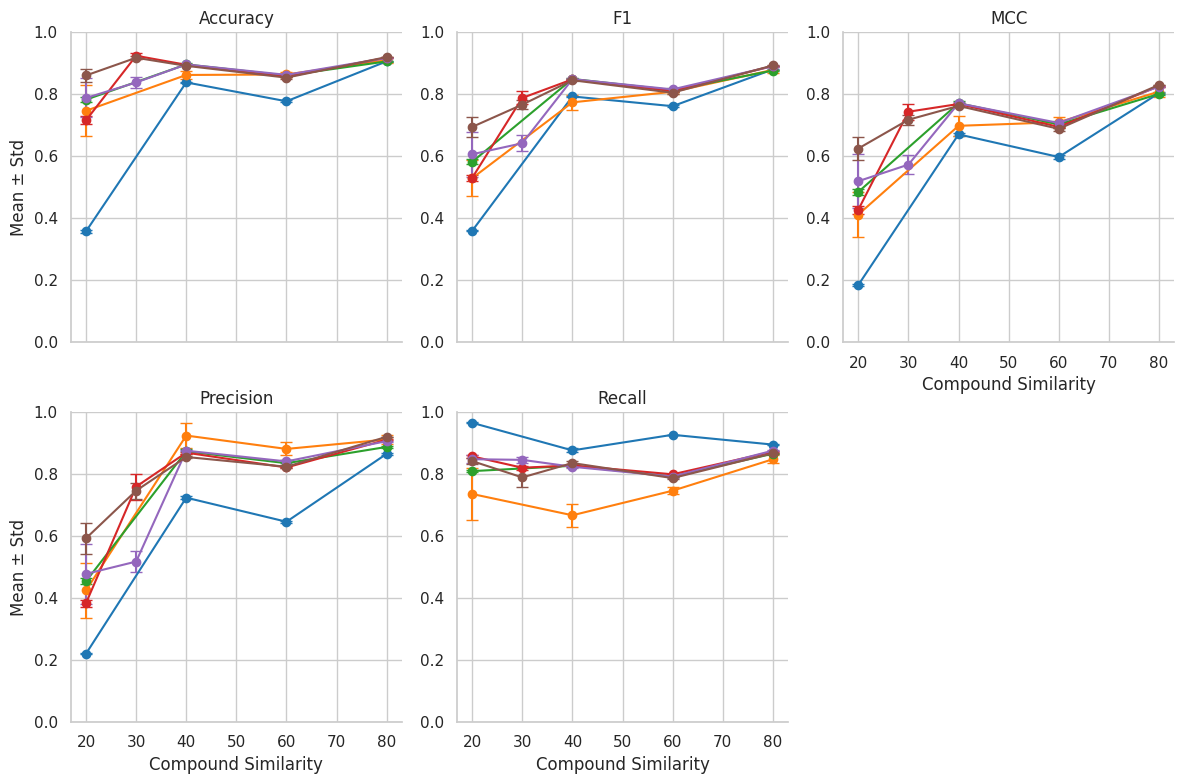

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Melt for easier grouping
df_melted = results.melt(id_vars=['model', 'similarity'],
                    value_vars=['Accuracy', 'F1', 'Recall', 'Precision', 'MCC'],
                    var_name='metric', value_name='value')
                    

# Compute mean and std
summary_df = df_melted.groupby(['model', 'similarity', 'metric']).agg(
    mean=('value', 'mean'),
    std=('value', 'std')
).reset_index()

# Set plot style
sns.set(style="whitegrid")
palette = sns.color_palette("tab10")

# Create FacetGrid
g = sns.FacetGrid(summary_df, col='metric', col_wrap=3, height=4, sharey=False, hue='model', palette=palette)

# Plot: lines + points + error bars
def plot_lines(data, color, **kwargs):
    # Sort by identity to ensure line plotting is correct
    data = data.sort_values('similarity')
    plt.errorbar(data['similarity'], data['mean'], yerr=data['std'], fmt='o-', 
                 capsize=4, color=color, label=data['model'].iloc[0])

g.map_dataframe(plot_lines)

# Titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("Compound Similarity", "Mean ± Std")
# g.add_legend(title="Model")
g.set(ylim=(0, 1))  # Set y-axis limits to [0, 1] for better visibility
g.tight_layout()
plt.savefig("results.png", dpi=300, transparent=True)
plt.show()
plt.close()

g.add_legend(title="Model")
g.savefig(f"legend_compounds.png", bbox_inches='tight', dpi=300, transparent=True)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Melt for easier grouping
df_melted = results.melt(id_vars=['model', 'similarity'],
                    value_vars=['accuracy', 'f1_score', 'recall', 'precision', 'roc_auc', 'mcc'],
                    var_name='metric', value_name='value')
                    

# Compute mean and std
summary_df = df_melted.groupby(['model', 'similarity', 'metric']).agg(
    mean=('value', 'mean'),
    std=('value', 'std')
).reset_index()

# Set plot style
sns.set(style="whitegrid")
palette = sns.color_palette("tab10")

# Create FacetGrid
g = sns.FacetGrid(summary_df, col='metric', col_wrap=3, height=4, sharey=False, hue='model', palette=palette)

# Plot: lines + points + error bars
def plot_lines(data, color, **kwargs):
    # Sort by identity to ensure line plotting is correct
    data = data.sort_values('similarity')
    plt.errorbar(data['similarity'], data['mean'], yerr=data['std'], fmt='o-', 
                 capsize=4, color=color, label=data['model'].iloc[0])

g.map_dataframe(plot_lines)

# Titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("Compound Similarity", "Mean ± Std")
g.add_legend(title="Model")
g.set(ylim=(0, 1))  # Set y-axis limits to [0, 1] for better visibility
g.tight_layout()
plt.savefig("results.png", dpi=300, transparent=True)
plt.show()

KeyError: "The following 'value_vars' are not present in the DataFrame: ['accuracy', 'f1_score', 'mcc', 'precision', 'recall']"

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_results = pairwise_tukeyhsd(
    endog=results[results["similarity"]==60]['f1_score'],  # Dependent variable
    groups=results[results["similarity"]==60]['model'],   # Grouping variable
    alpha=0.05                 # Significance level
)

# Print the results
print(tukey_results)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2  meandiff p-adj  lower  upper  reject
-----------------------------------------------------
    ESP  NP-ESM2   0.0465    0.0 0.0361 0.0569   True
    ESP ProSmith   0.0518    0.0 0.0415 0.0622   True
NP-ESM2 ProSmith   0.0053 0.3836 -0.005 0.0157  False
-----------------------------------------------------


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_results = pairwise_tukeyhsd(
    endog=results[results["identity"]==60]['mcc'],  # Dependent variable
    groups=results[results["identity"]==60]['model'],   # Grouping variable
    alpha=0.05                 # Significance level
)

# Print the results
print(tukey_results)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2  meandiff p-adj  lower  upper  reject
-----------------------------------------------------
    ESP  NP-ESM2   0.2765    0.0 0.1966 0.3564   True
    ESP ProSmith   0.3174    0.0 0.2375 0.3974   True
NP-ESM2 ProSmith   0.0409 0.3885 -0.039 0.1209  False
-----------------------------------------------------


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_results = pairwise_tukeyhsd(
    endog=results['recall'],  # Dependent variable
    groups=results['model'],   # Grouping variable
    alpha=0.05                 # Significance level
)

# Print the results
print(tukey_results)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower   upper  reject
-------------------------------------------------------
    ESP  NP-ESM2  -0.2104    0.0 -0.2602 -0.1607   True
    ESP ProSmith  -0.1825    0.0 -0.2323 -0.1328   True
NP-ESM2 ProSmith   0.0279 0.3697 -0.0219  0.0777  False
-------------------------------------------------------


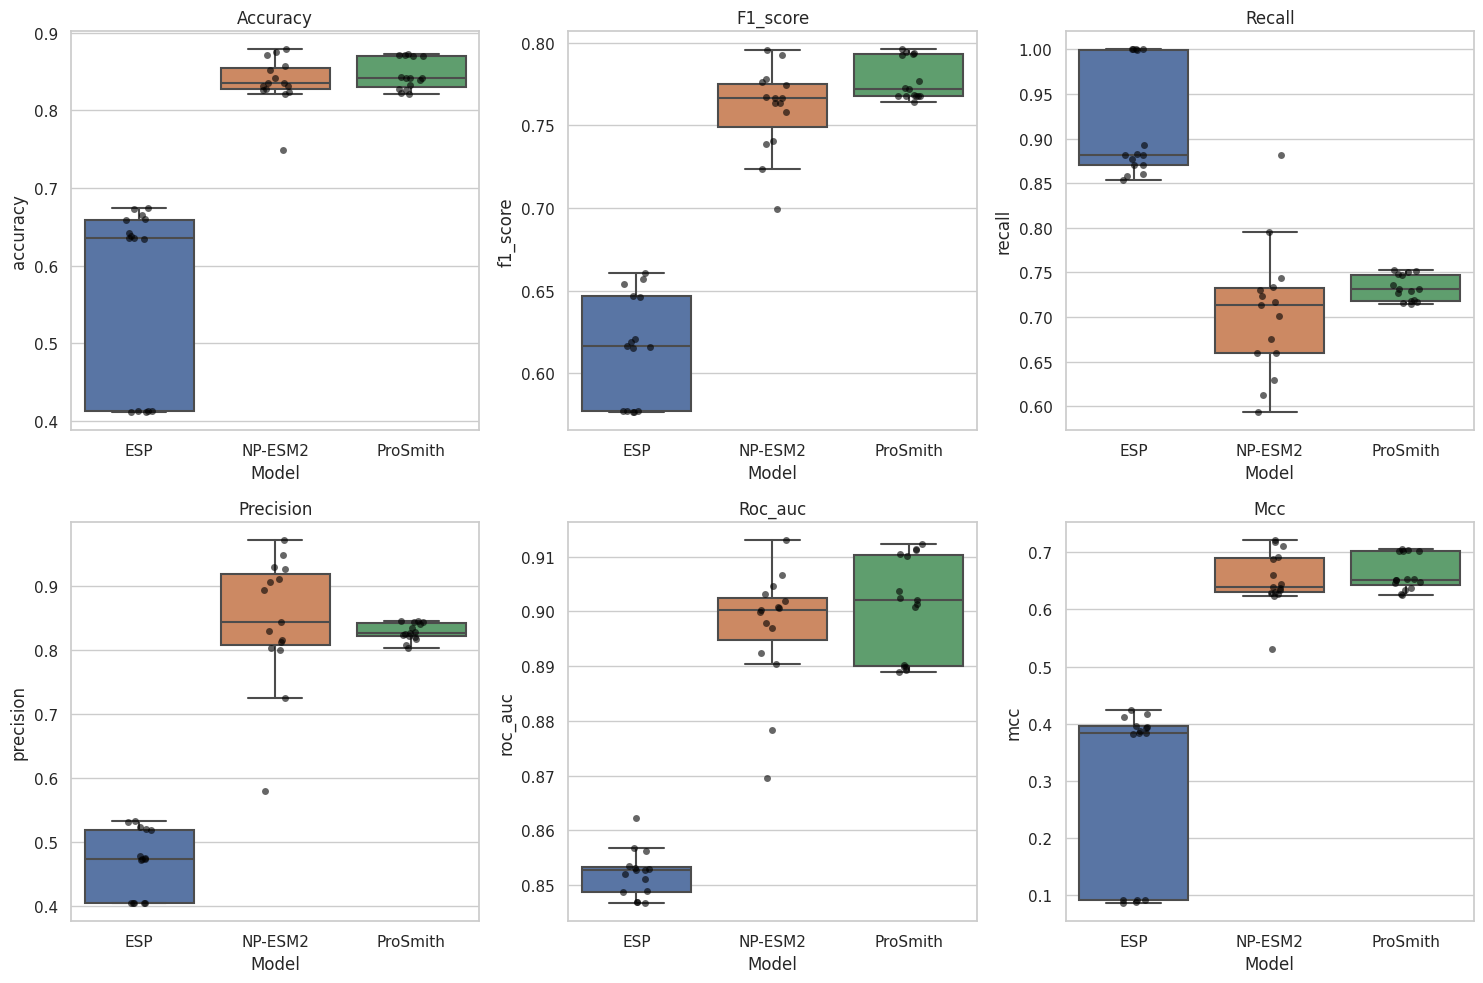

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

# Define the metrics to plot
metrics = ['accuracy', 'f1_score', 'recall', 'precision', 'roc_auc', 'mcc']

# Create boxplots for each metric with datapoints
plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=results, x='model', y=metric, showfliers=False)
    sns.stripplot(data=results, x='model', y=metric, color='black', alpha=0.6, jitter=True)
    plt.title(f'{metric.capitalize()}')
    plt.xlabel('Model')
    plt.ylabel(metric)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

np_esm2_results = pd.read_csv("results_np_classifier.csv")
np_esm2_results["model"] = "NP-ESM2"
np_esm2_results = np_esm2_results.rename(columns={"f1_macro": "f1_score"})

import pandas as pd

np_esm2_gat_results = pd.read_csv("results_gat_np_classifier.csv")
np_esm2_gat_results["model"] = "NP-ESM2-GAT"
np_esm2_gat_results = np_esm2_gat_results.rename(columns={"f1_macro": "f1_score"})

import pandas as pd

np_esm2_focal_bce_results = pd.read_csv("results_np_classifier_focal_bce.csv")
np_esm2_focal_bce_results["model"] = "NP-ESM2-FocalBCE"
np_esm2_focal_bce_results = np_esm2_focal_bce_results.rename(columns={"f1_macro": "f1_score"})

np_esm2_bce_results = pd.read_csv("results_np_classifier_bce.csv")
np_esm2_bce_results["model"] = "NP-ESM2-BCE"
np_esm2_bce_results = np_esm2_bce_results.rename(columns={"f1_macro": "f1_score"})


In [ ]:
results = pd.concat(
    [
        np_esm2_results,
        np_esm2_gat_results,
        np_esm2_focal_bce_results,
        np_esm2_bce_results
        
    ]
)


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_results = pairwise_tukeyhsd(
    endog=results['f1_score'],  # Dependent variable
    groups=results['model'],   # Grouping variable
    alpha=0.05                 # Significance level
)

# Print the results
print(tukey_results)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           group2      meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------
         NP-ESM2      NP-ESM2-BCE   0.0213 0.7018 -0.0348 0.0775  False
         NP-ESM2 NP-ESM2-FocalBCE  -0.0065 0.9872 -0.0626 0.0497  False
         NP-ESM2      NP-ESM2-GAT   0.0209  0.716 -0.0353  0.077  False
     NP-ESM2-BCE NP-ESM2-FocalBCE  -0.0278 0.5072 -0.0839 0.0283  False
     NP-ESM2-BCE      NP-ESM2-GAT  -0.0005    1.0 -0.0566 0.0557  False
NP-ESM2-FocalBCE      NP-ESM2-GAT   0.0273 0.5215 -0.0288 0.0835  False
-----------------------------------------------------------------------


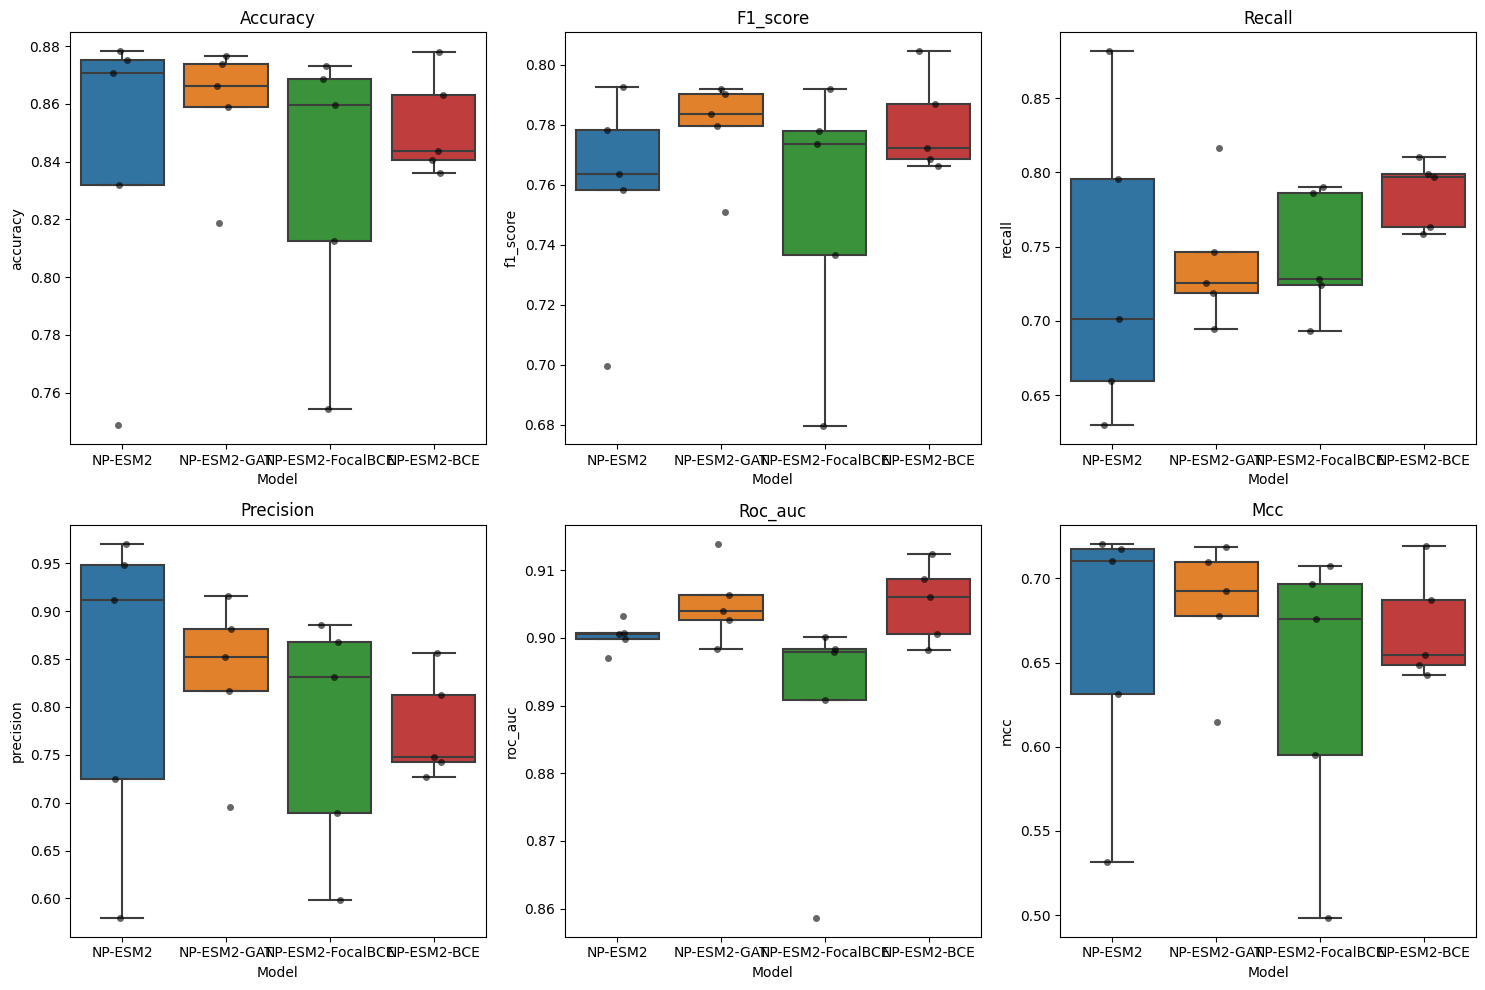

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

# Define the metrics to plot
metrics = ['accuracy', 'f1_score', 'recall', 'precision', 'roc_auc', 'mcc']

# Create boxplots for each metric with datapoints
plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=results, x='model', y=metric, showfliers=False)
    sns.stripplot(data=results, x='model', y=metric, color='black', alpha=0.6, jitter=True)
    plt.title(f'{metric.capitalize()}')
    plt.xlabel('Model')
    plt.ylabel(metric)

plt.tight_layout()
plt.show()